In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [2]:
print(df.shape)
print(df.isnull().sum())

(1000, 8)
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [3]:
print(df.describe())

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


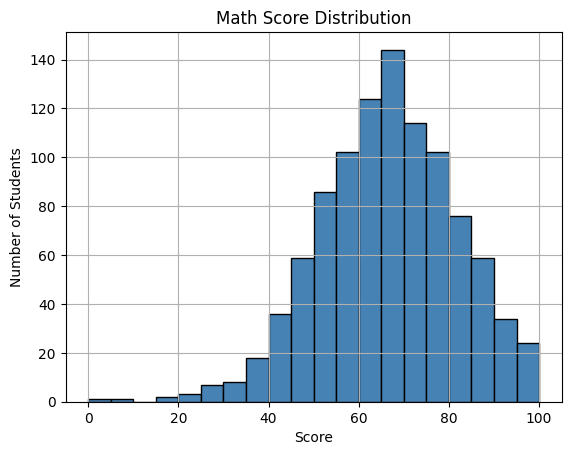

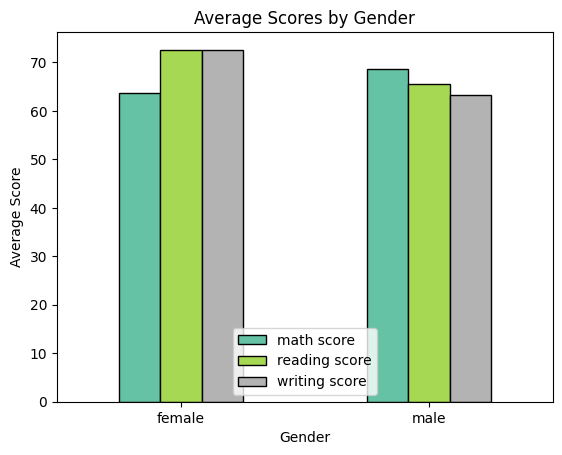

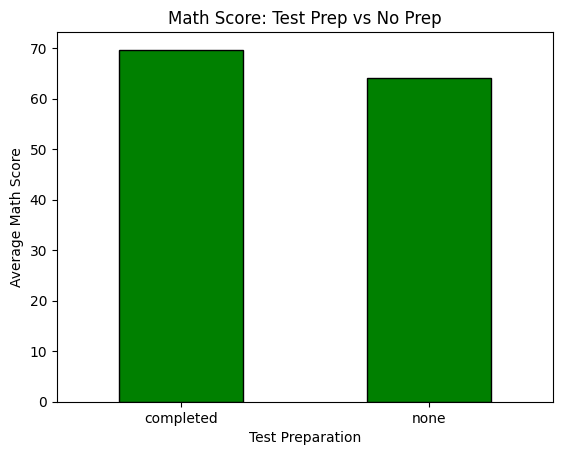

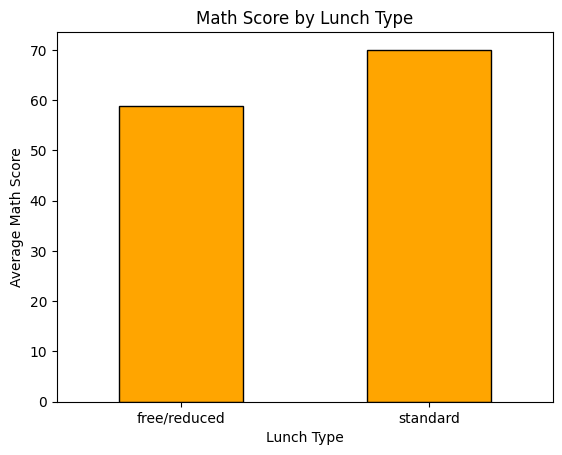

In [4]:
# Chart 1 - Math score distribution
df['math score'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Math Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.show()

# Chart 2 - Average scores by gender
df.groupby('gender')[['math score','reading score','writing score']].mean().plot(kind='bar', colormap='Set2', edgecolor='black')
plt.title('Average Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

# Chart 3 - Test preparation vs math score
df.groupby('test preparation course')['math score'].mean().plot(kind='bar', color='green', edgecolor='black')
plt.title('Math Score: Test Prep vs No Prep')
plt.xlabel('Test Preparation')
plt.ylabel('Average Math Score')
plt.xticks(rotation=0)
plt.show()

# Chart 4 - Lunch type vs math score
df.groupby('lunch')['math score'].mean().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Math Score by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Average Math Score')
plt.xticks(rotation=0)
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Predict math score from reading and writing scores
X = df[['reading score', 'writing score']]
y = df['math score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Model Score (R²): {model.score(X_test, y_test):.2f}")

# Predict for a student with reading=75, writing=80
print(f"Predicted Math Score: {model.predict([[75, 80]])[0]:.1f}")

Mean Absolute Error: 7.35
Model Score (R²): 0.68
Predicted Math Score: 72.8


C:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [6]:
print("=== PROJECT SUMMARY ===")
print(f"Dataset: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Average Math Score: {df['math score'].mean():.1f}/100")
print(f"Average Reading Score: {df['reading score'].mean():.1f}/100")
print(f"Average Writing Score: {df['writing score'].mean():.1f}/100")
print(f"Model Accuracy (R²): {model.score(X_test, y_test):.0%}")
print(f"Average Prediction Error: {mae:.2f} points")
print("\nKey Findings:")
print("- Males score higher in math, females in reading and writing")
print("- Test preparation improves math scores by ~6 points")
print("- Standard lunch students score ~11 points higher than free/reduced")

=== PROJECT SUMMARY ===
Dataset: 1000 students, 8 columns
Average Math Score: 66.1/100
Average Reading Score: 69.2/100
Average Writing Score: 68.1/100
Model Accuracy (R²): 68%
Average Prediction Error: 7.35 points

Key Findings:
- Males score higher in math, females in reading and writing
- Test preparation improves math scores by ~6 points
- Standard lunch students score ~11 points higher than free/reduced


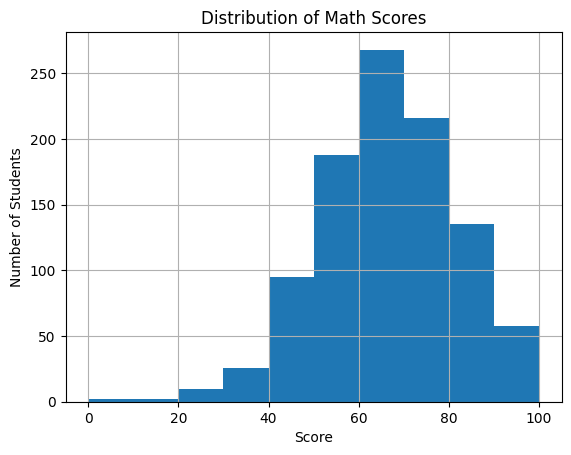

In [7]:
import matplotlib.pyplot as plt

plt.figure()
df['math score'].hist()
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.show()

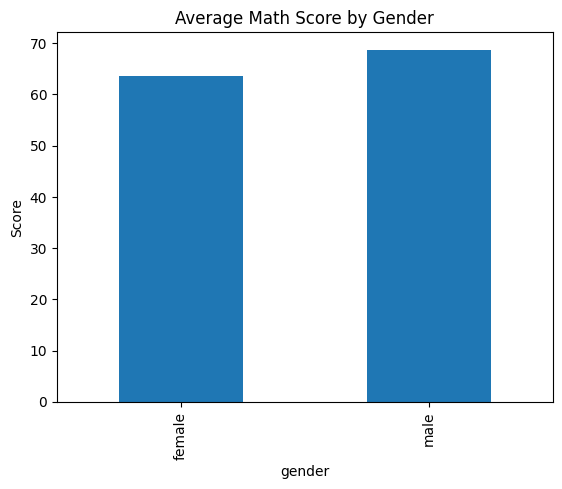

In [8]:
df.groupby('gender')['math score'].mean().plot(kind='bar')
plt.title("Average Math Score by Gender")
plt.ylabel("Score")
plt.show()

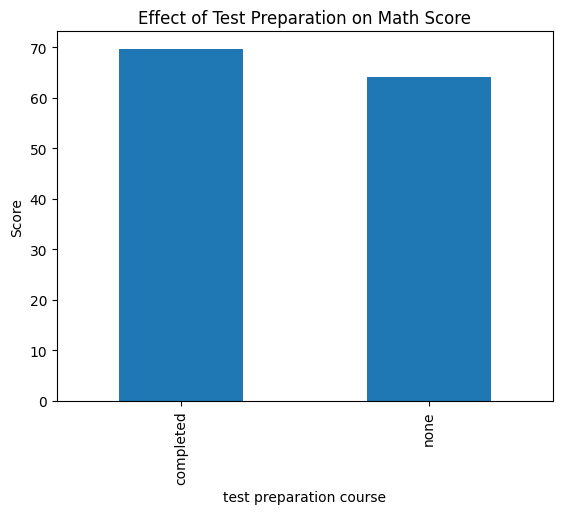

In [9]:
df.groupby('test preparation course')['math score'].mean().plot(kind='bar')
plt.title("Effect of Test Preparation on Math Score")
plt.ylabel("Score")
plt.show()

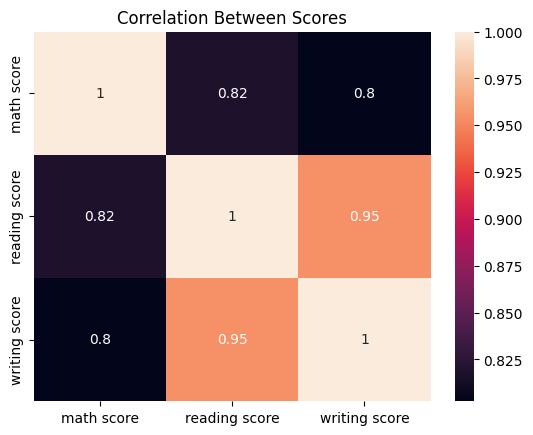

In [11]:
import seaborn as sns

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Scores")
plt.show()